In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/raw/StressLevelDataset_dirty.csv")
df.head(10)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,18.0,8.0,1,25.0,3,3.0,Good,5.0,3,1,...,2,1.0,5,2.0,5.0,1.0,NaN,5.0,4.0,High
1,6.0,26.0,0,8.0,1,2.0,Average,2.0,2,4,...,4,4.0,1,4.0,1.0,3.0,2.0,NaN,1.0,Low
2,5.0,25.0,NaN,6.0,1,2.0,Average,1.0,2,4,...,4,4.0,2,NaN,1.0,3.0,2.0,1.0,1.0,Low
3,12.0,23.0,1,10.0,3,1.0,Poor,2.0,2,3,...,2,2.0,3,3.0,3.0,3.0,NaN,3.0,3.0,Medium
4,19.0,15.0,1,27.0,5,NaN,Poor,4.0,5,2,...,2,2.0,5,1.0,4.0,1.0,4.0,5.0,5.0,High
5,3.0,26.0,0,8.0,1,NaN,Average,NaN,2,3,...,5,5.0,2,4.0,1.0,3.0,1.0,1.0,1.0,Low
6,16.0,11.0,false,22.0,5,3.0,Poor,4.0,4,2,...,2,1.0,5,2.0,5.0,1.0,4.0,5.0,5.0,High
7,8.0,28.0,0,4.0,1,2.0,Average,2.0,1,3,...,5,5.0,2,5.0,NaN,3.0,2.0,2.0,1.0,Low
8,12.0,NaN,0,11.0,3,1.0,Poor,2.0,2,3,...,3,3.0,3,2.0,3.0,2.0,2.0,2.0,3.0,Low
9,20.0,14.0,1,NaN,5,NaN,Poor,5.0,4,2,...,2,2.0,4,2.0,NaN,1.0,5.0,NaN,5.0,High


In [3]:
df.shape

(1118, 21)

In [4]:
df.columns 

Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'stress_level'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 1039 non-null   float64
 1   self_esteem                   1049 non-null   float64
 2   mental_health_history         1020 non-null   str    
 3   depression                    1063 non-null   float64
 4   headache                      1118 non-null   int64  
 5   blood_pressure                1008 non-null   float64
 6   sleep_quality                 1028 non-null   str    
 7   breathing_problem             1051 non-null   float64
 8   noise_level                   1118 non-null   int64  
 9   living_conditions             1118 non-null   int64  
 10  safety                        1118 non-null   int64  
 11  basic_needs                   1118 non-null   int64  
 12  academic_performance          1118 non-null   float64
 13  study_load    

In [6]:
df.describe()

,anxiety_level,self_esteem,depression,headache,blood_pressure,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying
count,1039.000000,1049.000000,1063.000000,1118.000000,1008.000000,1051.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1052.000000,1061.000000,995.000000,1039.000000,1017.000000,1027.000000
mean,11.887392,17.843661,12.921919,2.511628,2.177579,2.764986,2.649374,2.516995,2.727191,2.771914,2.769678,2.626118,2.649240,2.641847,1.887437,2.719923,2.751229,2.605648
std,8.603211,9.413546,8.317868,1.407026,0.875130,1.406431,1.322810,1.115199,1.401430,1.428962,1.402595,1.314378,1.379326,1.517167,1.040137,1.430300,1.404458,1.518337
min,0.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,7.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000
50%,11.000000,19.000000,12.000000,3.000000,2.000000,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000
75%,17.000000,26.000000,19.000000,3.000000,3.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000
max,92.000000,99.000000,59.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000


In [7]:
df.isna().sum()

anxiety_level                    79
self_esteem                      69
mental_health_history            98
depression                       55
headache                          0
blood_pressure                  110
sleep_quality                    90
breathing_problem                67
noise_level                       0
living_conditions                 0
safety                            0
basic_needs                       0
academic_performance              0
study_load                        0
teacher_student_relationship     66
future_career_concerns           57
social_support                  123
peer_pressure                    79
extracurricular_activities      101
bullying                         91
stress_level                      0
dtype: int64

In [8]:
df.dropna(inplace=False)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
6,16.0,11.0,false,22.0,5,3.0,Poor,4.0,4,2,...,2,1.0,5,2.0,5.0,1.0,4.0,5.0,5.0,High
18,18.0,10.0,1,23.0,3,3.0,Poor,5.0,5,1,...,2,2.0,4,1.0,4.0,1.0,4.0,4.0,4.0,High
22,7.0,25.0,0,0.0,1,2.0,Average,2.0,1,4,...,5,4.0,2,5.0,1.0,3.0,1.0,1.0,1.0,Low
25,13.0,24.0,1,10.0,2,1.0,Poor,4.0,2,2,...,2,2.0,3,3.0,3.0,2.0,2.0,2.0,3.0,Medium
27,21.0,28.0,0,20.0,0,3.0,Poor,0.0,5,4,...,4,2.0,4,2.0,0.0,0.0,5.0,0.0,5.0,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097,16.0,15.0,0,14.0,4,3.0,Average,5.0,1,2,...,5,3.0,1,1.0,1.0,1.0,5.0,2.0,2.0,High
1100,7.0,27.0,0,7.0,1,2.0,Average,2.0,1,4,...,5,4.0,2,4.0,1.0,3.0,1.0,1.0,1.0,Low
1104,21.0,1.0,1,17.0,3,3.0,Poor,4.0,5,1,...,1,1.0,4,2.0,5.0,1.0,5.0,5.0,5.0,High
1107,8.0,25.0,0,5.0,1,2.0,Average,1.0,2,4,...,4,4.0,1,4.0,1.0,3.0,1.0,2.0,1.0,Low


In [9]:
temp = df['mental_health_history'].astype(str).str.strip().str.lower()

print(temp.unique())

<StringArray>
['1', '0', nan, 'false', 'n', '1.1', 'y', 'yes', 'true', 'no']
Length: 10, dtype: str


In [10]:
temp = df['mental_health_history'].astype(str).str.strip().str.lower()

yes_vals = ['1', 'true', 'yes', 'y']
no_vals = ['0', 'false', 'no', 'n']

temp = temp.apply(lambda x: 1 if (x in yes_vals or x == '1.1') 
                  else (0 if x in no_vals else None))

# fill missing
temp.fillna(temp.mode()[0], inplace=True)

# convert to int
df['mental_health_history'] = temp.astype(int)

In [11]:
df['mental_health_history'].isna().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 1039 non-null   float64
 1   self_esteem                   1049 non-null   float64
 2   mental_health_history         1118 non-null   int64  
 3   depression                    1063 non-null   float64
 4   headache                      1118 non-null   int64  
 5   blood_pressure                1008 non-null   float64
 6   sleep_quality                 1028 non-null   str    
 7   breathing_problem             1051 non-null   float64
 8   noise_level                   1118 non-null   int64  
 9   living_conditions             1118 non-null   int64  
 10  safety                        1118 non-null   int64  
 11  basic_needs                   1118 non-null   int64  
 12  academic_performance          1118 non-null   float64
 13  study_load    

In [13]:
df['mental_health_history'][2]


np.int64(0)

In [14]:
print(df['sleep_quality'].unique())
print(df['stress_level'].unique())

<StringArray>
['Good', 'Average', 'Poor', nan]
Length: 4, dtype: str
<StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str


In [15]:
# Step 1: Clean sleep_quality
df['sleep_quality'] = (
    df['sleep_quality']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Step 2: Replace 'nan' string back to actual NaN (important)
df['sleep_quality'].replace('nan', np.nan, inplace=True)

# Step 3: Conditional imputation using stress_level
df['sleep_quality'] = df.groupby('stress_level')['sleep_quality'].transform(lambda x: x.fillna(x.mode()[0]))

In [16]:
df['sleep_quality'].isna().sum()

np.int64(0)

In [17]:
df['sleep_quality']

0          good
1       average
2       average
3          poor
4          poor
         ...   
1113       poor
1114    average
1115       poor
1116       poor
1117       poor
Name: sleep_quality, Length: 1118, dtype: str

In [18]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[
    ['poor', 'average', 'good'],   # sleep_quality
    ['Low', 'Medium', 'High']      # stress_level
])

df[['sleep_quality', 'stress_level']] = encoder.fit_transform(
    df[['sleep_quality', 'stress_level']]
)

df[['sleep_quality', 'stress_level']] = df[['sleep_quality', 'stress_level']].astype(int)

In [19]:
print(df['stress_level'].unique())
print(df['sleep_quality'].unique())

[2 0 1]
[2 1 0]


In [20]:
df.head(5)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,18.0,8.0,1,25.0,3,3.0,2,5.0,3,1,...,2,1.0,5,2.0,5.0,1.0,NaN,5.0,4.0,2
1,6.0,26.0,0,8.0,1,2.0,1,2.0,2,4,...,4,4.0,1,4.0,1.0,3.0,2.0,NaN,1.0,0
2,5.0,25.0,0,6.0,1,2.0,1,1.0,2,4,...,4,4.0,2,NaN,1.0,3.0,2.0,1.0,1.0,0
3,12.0,23.0,1,10.0,3,1.0,0,2.0,2,3,...,2,2.0,3,3.0,3.0,3.0,NaN,3.0,3.0,1
4,19.0,15.0,1,27.0,5,NaN,0,4.0,5,2,...,2,2.0,5,1.0,4.0,1.0,4.0,5.0,5.0,2


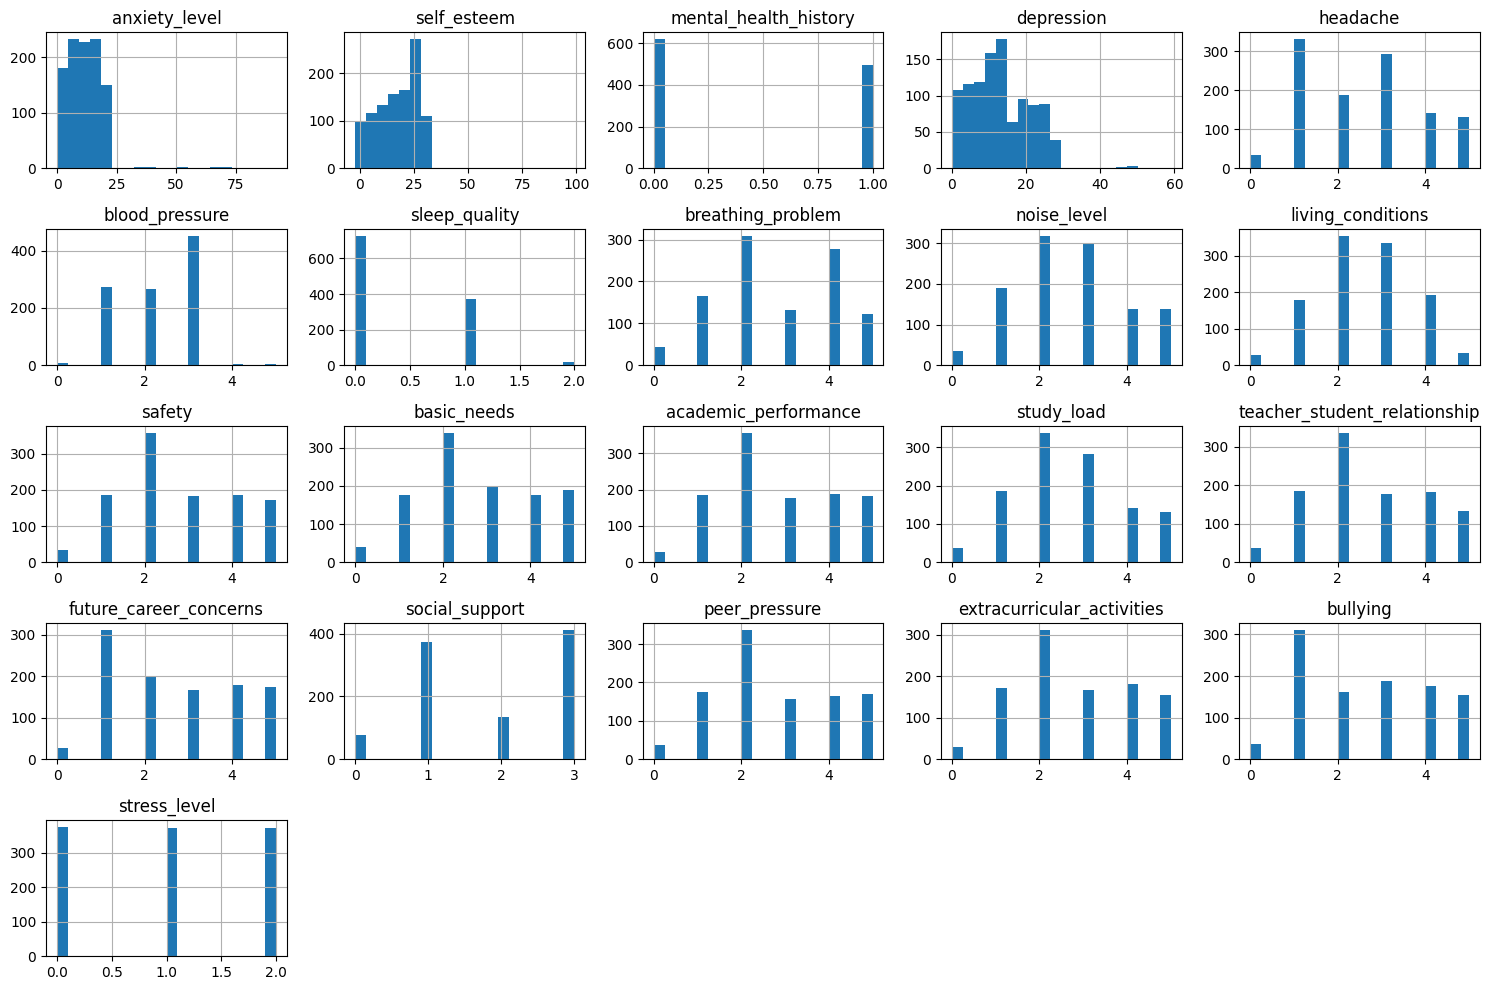

In [21]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

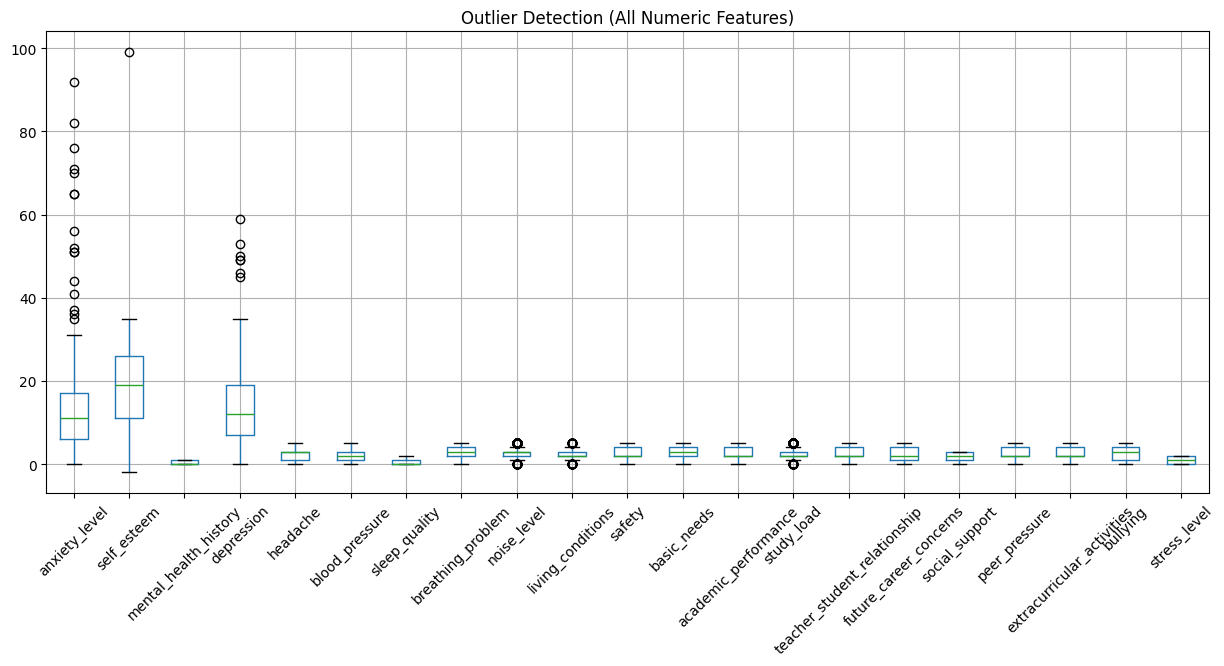

In [22]:
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.boxplot(figsize=(15,6))
plt.title("Outlier Detection (All Numeric Features)")
plt.xticks(rotation=45)
plt.show()

In [23]:
for col in ['anxiety_level', 'self_esteem', 'depression']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

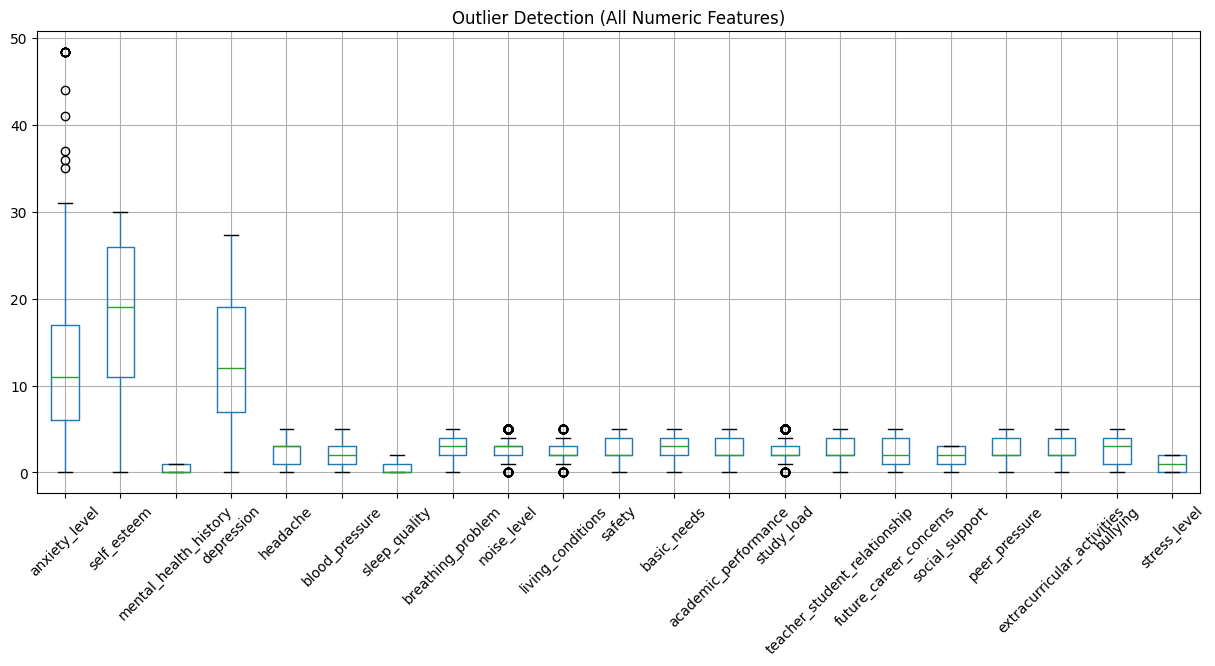

In [24]:
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.boxplot(figsize=(15,6))
plt.title("Outlier Detection (All Numeric Features)")
plt.xticks(rotation=45)
plt.show()

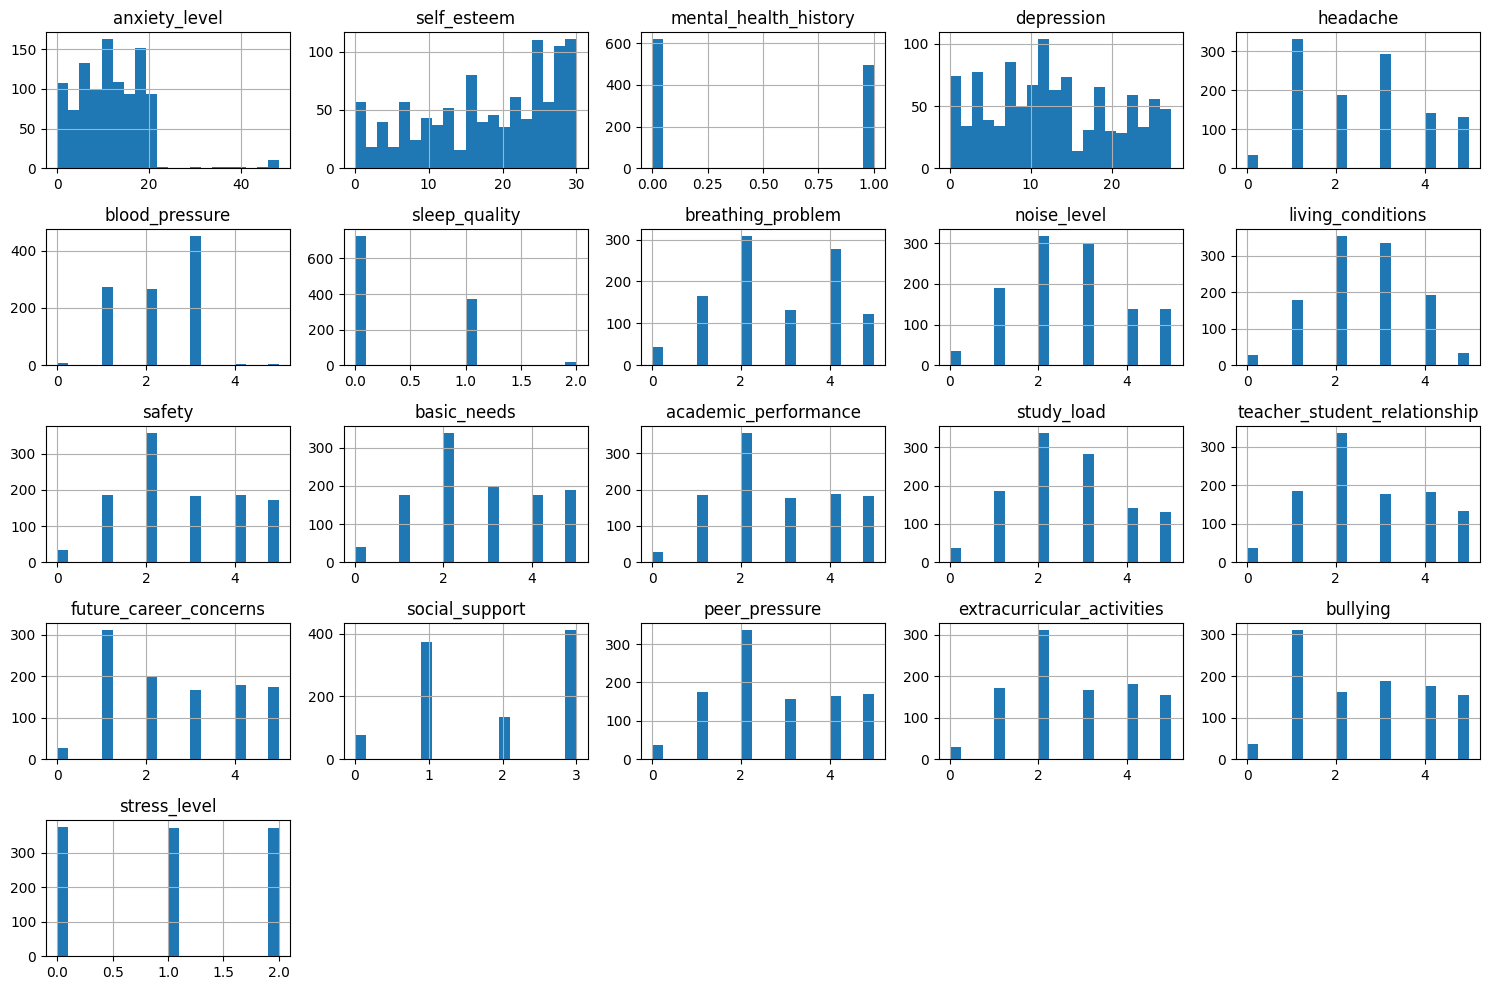

In [25]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

In [26]:
df.isna().sum()

anxiety_level                    79
self_esteem                      69
mental_health_history             0
depression                       55
headache                          0
blood_pressure                  110
sleep_quality                     0
breathing_problem                67
noise_level                       0
living_conditions                 0
safety                            0
basic_needs                       0
academic_performance              0
study_load                        0
teacher_student_relationship     66
future_career_concerns           57
social_support                  123
peer_pressure                    79
extracurricular_activities      101
bullying                         91
stress_level                      0
dtype: int64

In [27]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Copy data
df_knn = df.copy()

# Separate target
y = df_knn['academic_performance']
X = df_knn.drop('academic_performance', axis=1)

# Scale (IMPORTANT for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KNN
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_scaled)

# Convert back
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

# Combine back
df_knn = pd.concat([X_imputed, y.reset_index(drop=True)], axis=1)

# Fix ordinal columns (VERY IMPORTANT)
ordinal_cols = [
    'sleep_quality','stress_level','mental_health_history',
    'headache','noise_level','living_conditions','safety',
    'basic_needs','study_load'
]

df_knn[ordinal_cols] = df_knn[ordinal_cols].round().astype(int)

In [28]:
# from sklearn.impute import KNNImputer
# from sklearn.preprocessing import StandardScaler
# import pandas as pd

# df_hybrid = df.copy()

# # -------------------------------
# # STEP 1: High-impact columns (KNN)
# # -------------------------------

# high_cols = [
#     'teacher_student_relationship',
#     'safety',
#     'basic_needs',
#     'self_esteem'
# ]

# scaler = StandardScaler()
# scaled = scaler.fit_transform(df_hybrid[high_cols])

# imputer = KNNImputer(n_neighbors=5)
# df_hybrid[high_cols] = imputer.fit_transform(scaled)

# # -------------------------------
# # STEP 2: Medium + Low → median
# # -------------------------------

# rest_cols = df_hybrid.columns.difference(high_cols + ['academic_performance'])
# df_hybrid[rest_cols] = df_hybrid[rest_cols].fillna(df_hybrid[rest_cols].median())

# ordinal_cols = [
#     'sleep_quality','stress_level','mental_health_history',
#     'headache','noise_level','living_conditions','safety',
#     'basic_needs','study_load'
# ]

# df_hybrid[ordinal_cols] = df_hybrid[ordinal_cols].round().astype(int)

In [29]:
# from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer
# from sklearn.preprocessing import StandardScaler
# import pandas as pd
# import numpy as np

# df_iter = df.copy()

# # -------------------------------
# # STEP 1: Separate target
# # -------------------------------
# y = df_iter['academic_performance']
# X = df_iter.drop(columns=['academic_performance'])

# # -------------------------------
# # STEP 2: Scale (IMPORTANT)
# # -------------------------------
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # -------------------------------
# # STEP 3: Iterative Imputation
# # -------------------------------
# imputer = IterativeImputer(
#     max_iter=10,
#     random_state=42
# )

# X_imputed = imputer.fit_transform(X_scaled)

# # -------------------------------
# # STEP 4: Convert back
# # -------------------------------
# X_imputed = scaler.inverse_transform(X_imputed)
# X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

# # -------------------------------
# # STEP 5: Restore target
# # -------------------------------
# df_iter = pd.concat([X_imputed, y.reset_index(drop=True)], axis=1)

# # -------------------------------
# # STEP 6: Fix ordinal columns
# # -------------------------------
# ordinal_cols = [
#     'sleep_quality','stress_level','mental_health_history',
#     'headache','noise_level','living_conditions','safety',
#     'basic_needs','study_load'
# ]

# df_iter[ordinal_cols] = df_iter[ordinal_cols].round().astype(int)

In [30]:
df_knn.isna().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
academic_performance            0
dtype: int64

In [31]:
# cont_cols = [
#     'anxiety_level',
#     'self_esteem',
#     'depression'
# ]

# # Semi-continuous (bounded numeric)
# semi_cont_cols = [
#     'blood_pressure',
#     'breathing_problem',
#     'teacher_student_relationship',
#     'future_career_concerns',
#     'social_support',
#     'peer_pressure',
#     'extracurricular_activities',
#     'bullying'
# ]

# # Ordinal (ratings)
# ord_cols = [
#     'headache',
#     'noise_level',
#     'living_conditions',
#     'safety',
#     'basic_needs',
#     'study_load'
# ]

# # -------------------------------
# # STEP 2: HANDLE MISSING VALUES
# # -------------------------------

# # Continuous + Semi → MEDIAN
# num_cols = cont_cols + semi_cont_cols
# df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# # Ordinal → MODE
# df[ord_cols] = df[ord_cols].fillna(df[ord_cols].mode().iloc[0])

# # -------------------------------
# # STEP 3: FINAL CHECK
# # -------------------------------

# print("Remaining NaNs:\n", df.isna().sum())

In [32]:
drop_cols = ['noise_level', 'bullying']

df_fs = df_knn.drop(columns=drop_cols)

In [33]:
df_fs['env_score'] = (
    df_fs['safety'] +
    df_fs['basic_needs'] +
    df_fs['living_conditions']
)

df_fs['mental_score'] = (
    df_fs['anxiety_level'] +
    df_fs['depression'] -
    df_fs['self_esteem']
)

df_fs['pressure_score'] = (
    df_fs['peer_pressure'] +
    df_fs['study_load'] +
    df_fs['future_career_concerns']
)

df_fs['support_score'] = (
    df_fs['teacher_student_relationship'] +
    df_fs['social_support']
)


# df_fs['env_score'] = (
#     0.6 * df_fs['safety'] +
#     0.6 * df_fs['basic_needs'] +
#     0.5 * df_fs['living_conditions']
# )
# df_fs['mental_score'] = (
#     0.6 * df_fs['depression'] +
#     0.5 * df_fs['anxiety_level'] -
#     0.6 * df_fs['self_esteem']
# )
# df_fs['pressure_score'] = (
#     0.6 * df_fs['future_career_concerns'] +
#     0.5 * df_fs['peer_pressure'] +
#     0.5 * df_fs['study_load']
# )
# df_fs['support_score'] = (
#     0.6 * df_fs['teacher_student_relationship'] +
#     0.5 * df_fs['social_support']
# )
drop_cols = [
    'safety','basic_needs','living_conditions',
    'anxiety_level','depression','self_esteem',
    'peer_pressure','study_load','future_career_concerns',
    'teacher_student_relationship','social_support'
]

df_fs2 = df_fs.drop(columns=drop_cols)

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Models
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.preprocessing import StandardScaler

# -------------------------------
# STEP 1: Features & Target
# -------------------------------
X = df_fs2.drop(columns=['academic_performance'])
y = df_fs2['academic_performance']

# -------------------------------
# STEP 2: Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# STEP 3: Scaling (ONLY where needed)
# -------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# STEP 4: Define Models
# -------------------------------
models = {

    "AdaBoost": AdaBoostRegressor(
        n_estimators=300,
        learning_rate=0.03,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.03,
        max_depth=2,
        subsample=0.7,
        random_state=42
    ),

    "LinearRegression": LinearRegression(),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(alpha=0.01)
}

# -------------------------------
# STEP 5: Train & Evaluate
# -------------------------------
results = []

for name, model in models.items():

    # Scaling only for linear models
    if name in ["LinearRegression", "Ridge", "Lasso"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        train_pred = model.predict(X_train_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        train_pred = model.predict(X_train)

    results.append({
        "Model": name,
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred)
    })

# -------------------------------
# STEP 6: Results
# -------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Test R2", ascending=False)

print(results_df)

              Model  Train R2   Test R2       MAE       MSE
0          AdaBoost  0.648359  0.697723  0.651097  0.629228
1  GradientBoosting  0.682885  0.672406  0.664570  0.681930
2  LinearRegression  0.615272  0.652895  0.666758  0.722544
3             Ridge  0.615271  0.652869  0.666804  0.722597
4             Lasso  0.614941  0.652749  0.668157  0.722847
